In [7]:
file_path = "/content/drive/MyDrive/projet tal/testSentiment.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

reviews = [x.strip() for x in text.split("\n") if x.strip()]

print("Nombre de reviews :", len(reviews))

Nombre de reviews : 25000


# Movies — Improvements Notebook

Ce notebook est dédié **uniquement** aux améliorations du modèle baseline pour la classification de critiques de films (`P/N`).

## Objectifs
- repartir d'une base propre et reproductible
- optimiser le meilleur pipeline classique
- comparer **word n-grams**, **char n-grams**, et **LSA**
- évaluer avec les métriques demandées par le prof :
  - accuracy
  - precision
  - recall
  - f1

## Conseils d'utilisation
- garde le notebook baseline séparé
- exécute ce notebook indépendamment
- note dans un tableau les meilleurs essais avant de faire une soumission

## 1. Imports

In [1]:
from pathlib import Path
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer,
)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD

## 2. Chargement des données

Adapte `DATA_DIR` à ton Google Drive.
La structure attendue est :

```text
movies1000/
    pos/
    neg/
```

ou bien :

```text
movies1000/
    movies1000/
        pos/
        neg/
```

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/drive/MyDrive/projet tal/movies1000")

def load_movies_from_folder(data_dir: Path) -> pd.DataFrame:
    rows = []

    for label_folder, label in [("movies1000/pos", "P"), ("movies1000/neg", "N")]:
        folder = data_dir / label_folder
        for file_path in folder.glob("*.txt"):
            text = file_path.read_text(encoding="utf-8", errors="ignore")
            rows.append(
                {
                    "doc_id": file_path.name,
                    "label": label,
                    "text": text,
                }
            )

    df = pd.DataFrame(rows).sort_values("doc_id").reset_index(drop=True)
    return df

df = load_movies_from_folder(DATA_DIR)
print(df.shape)
df.head()


(2000, 3)


,doc_id,label,text
0,cv000_29416.txt,N,"plot : two teen couples go to a church party ,..."
1,cv000_29590.txt,P,films adapted from comic books have had plenty...
2,cv001_18431.txt,P,every now and then a movie comes along from a ...
3,cv001_19502.txt,N,the happy bastard's quick movie review \ndamn ...
4,cv002_15918.txt,P,you've got mail works alot better than it dese...


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Vérification rapide du corpus

Nombre total de documents : 2000

Répartition des classes :
label
N    1000
P    1000
Name: count, dtype: int64


,mean,median,std,min,max
label,,,,,
N,705.630,668.5,296.729759,17,2181
P,787.051,731.5,352.799881,130,2678


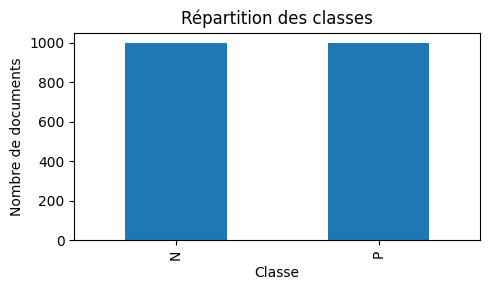

In [3]:
print("Nombre total de documents :", len(df))
print("\nRépartition des classes :")
print(df["label"].value_counts().sort_index())

df["n_words"] = df["text"].str.split().str.len()
display(df.groupby("label")["n_words"].agg(["mean", "median", "std", "min", "max"]))

fig, ax = plt.subplots(figsize=(5, 3))
df["label"].value_counts().sort_index().plot(kind="bar", ax=ax, title="Répartition des classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre de documents")
plt.tight_layout()
plt.show()

## 4. Préprocessing retenu

Dans le notebook baseline, la meilleure version était `v2_standard`.
On reprend donc un préprocessing **modéré** :
- minuscules
- suppression ponctuation
- suppression chiffres
- normalisation des espaces

On évite ici le stemming/lemmatisation agressifs, car ils avaient dégradé les résultats.

In [4]:
def preprocess_standard(text: str) -> str:
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_standard"] = df["text"].apply(preprocess_standard)
df[["text", "text_standard"]].head(3)

,text,text_standard
0,"plot : two teen couples go to a church party ,...",plot two teen couples go to a church party dri...
1,films adapted from comic books have had plenty...,films adapted from comic books have had plenty...
2,every now and then a movie comes along from a ...,every now and then a movie comes along from a ...


## 5. Split local train/validation

On garde un split local pour :
- comparer les meilleurs modèles plus en détail
- analyser les erreurs
- produire une matrice de confusion

La sélection principale se fera quand même via **cross-validation**.

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    df["text_standard"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"],
)

print("Train size :", len(X_train))
print("Valid size :", len(X_valid))

Train size : 1600
Valid size : 400


## 6. Métriques d'évaluation

Ici on utilise les métriques non-macro pour être aligné avec ce que tu m'as expliqué sur l'évaluation.
On considère `P` comme classe positive.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label="P"),
    "recall": make_scorer(recall_score, pos_label="P"),
    "f1": make_scorer(f1_score, pos_label="P"),
}

In [7]:
def evaluate_cv(model_dict, X, y, cv, scoring):
    rows = []
    for name, model in model_dict.items():
        scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        row = {"model": name}
        for metric_name in scoring.keys():
            values = scores[f"test_{metric_name}"]
            row[f"{metric_name}_mean"] = values.mean()
            row[f"{metric_name}_std"] = values.std()
        rows.append(row)
    return pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)

## 7. Rappel rapide de la baseline retenue

In [8]:
baseline_models = {
    "LinearSVC_tfidf_12": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", LinearSVC())
    ]),
    "LogReg_tfidf_12": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=3000))
    ]),
}

baseline_results = evaluate_cv(baseline_models, df["text_standard"], df["label"], cv, scoring)
baseline_results

## 8. Amélioration A — GridSearch sur TF-IDF mots + LinearSVC

Ici on optimise le meilleur pipeline classique sur :
- `ngram_range`
- `min_df`
- `max_df`
- `sublinear_tf`
- `C`

### Rappel
- `min_df` : ignore les mots trop rares
- `max_df` : ignore les mots trop fréquents
- `sublinear_tf=True` : remplace la fréquence brute par une version logarithmique

In [ ]:
svm_word_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

param_grid_word = {
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.95, 1.0],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.5, 1.0, 2.0],
}

grid_word = GridSearchCV(
    estimator=svm_word_pipeline,
    param_grid=param_grid_word,
    scoring=make_scorer(f1_score, pos_label="P"),
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_word.fit(df["text_standard"], df["label"])

print("Best word-level score:", grid_word.best_score_)
print("Best word-level params:")
print(grid_word.best_params_)

In [ ]:
results_word = pd.DataFrame(grid_word.cv_results_)
cols_word = [
    "mean_test_score",
    "std_test_score",
    "param_tfidf__ngram_range",
    "param_tfidf__min_df",
    "param_tfidf__max_df",
    "param_tfidf__sublinear_tf",
    "param_clf__C",
]
results_word[cols_word].sort_values("mean_test_score", ascending=False).head(10)

,mean_test_score,std_test_score,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__max_df,param_tfidf__sublinear_tf,param_clf__C
87,0.884884,0.010276,"(1, 2)",3,0.95,True,2.0
81,0.884573,0.007983,"(1, 2)",2,0.95,True,2.0
69,0.884105,0.009849,"(1, 2)",3,1.00,True,1.0
51,0.883651,0.010504,"(1, 2)",3,0.95,True,1.0
99,0.883339,0.009496,"(1, 2)",2,1.00,True,2.0
105,0.882209,0.011675,"(1, 2)",3,1.00,True,2.0
107,0.881878,0.011952,"(1, 3)",3,1.00,True,2.0
45,0.881055,0.009827,"(1, 2)",2,0.95,True,1.0
89,0.881001,0.013047,"(1, 3)",3,0.95,True,2.0
63,0.880928,0.009661,"(1, 2)",2,1.00,True,1.0


## 9. Amélioration B — TF-IDF caractères + LinearSVC

Les `char n-grams` peuvent capturer :
- fragments de mots
- variations morphologiques
- expressions locales
- robustesse à certaines variations de surface

Ce test est souvent intéressant en classification textuelle.

In [ ]:
svm_char_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char")),
    ("clf", LinearSVC())
])

param_grid_char = {
    "tfidf__ngram_range": [(3, 5), (4, 6), (3, 6)],
    "tfidf__min_df": [1, 2],
    "tfidf__sublinear_tf": [False, True],
    "clf__C": [0.5, 1.0, 2.0],
}

grid_char = GridSearchCV(
    estimator=svm_char_pipeline,
    param_grid=param_grid_char,
    scoring=make_scorer(f1_score, pos_label="P"),
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_char.fit(df["text_standard"], df["label"])

print("Best char-level score:", grid_char.best_score_)
print("Best char-level params:")
print(grid_char.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best char-level score: 0.8784232302469288
Best char-level params:
{'clf__C': 1.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (3, 6), 'tfidf__sublinear_tf': True}


In [ ]:
results_char = pd.DataFrame(grid_char.cv_results_)
cols_char = [
    "mean_test_score",
    "std_test_score",
    "param_tfidf__ngram_range",
    "param_tfidf__min_df",
    "param_tfidf__sublinear_tf",
    "param_clf__C",
]
results_char[cols_char].sort_values("mean_test_score", ascending=False).head(10)

,mean_test_score,std_test_score,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__sublinear_tf,param_clf__C
23,0.878423,0.014099,"(3, 6)",2,True,1.0
33,0.877558,0.012046,"(4, 6)",2,True,2.0
17,0.877407,0.011721,"(3, 6)",1,True,1.0
27,0.876713,0.011020,"(4, 6)",1,True,2.0
15,0.876479,0.011843,"(4, 6)",1,True,1.0
21,0.876324,0.010660,"(4, 6)",2,True,1.0
35,0.875427,0.012812,"(3, 6)",2,True,2.0
29,0.875114,0.013845,"(3, 6)",1,True,2.0
11,0.873615,0.013263,"(3, 6)",2,True,0.5
9,0.872841,0.014465,"(4, 6)",2,True,0.5


## 10. Amélioration C — LSA (TF-IDF + TruncatedSVD) + LogisticRegression

Ici on projette TF-IDF dans un espace latent plus compact avec `TruncatedSVD`.
C'est une piste intéressante vue en cours, à comparer aux représentations brutes TF-IDF.

In [ ]:
lsa_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)),
    ("svd", TruncatedSVD(random_state=42)),
    ("clf", LogisticRegression(max_iter=3000))
])

param_grid_lsa = {
    "svd__n_components": [100, 200, 300],
    "clf__C": [0.5, 1.0, 2.0],
}

grid_lsa = GridSearchCV(
    estimator=lsa_pipeline,
    param_grid=param_grid_lsa,
    scoring=make_scorer(f1_score, pos_label="P"),
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_lsa.fit(df["text_standard"], df["label"])

print("Best LSA score:", grid_lsa.best_score_)
print("Best LSA params:")
print(grid_lsa.best_params_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best LSA score: 0.8307282259095391
Best LSA params:
{'clf__C': 2.0, 'svd__n_components': 300}


In [ ]:
results_lsa = pd.DataFrame(grid_lsa.cv_results_)
cols_lsa = [
    "mean_test_score",
    "std_test_score",
    "param_svd__n_components",
    "param_clf__C",
]
results_lsa[cols_lsa].sort_values("mean_test_score", ascending=False).head(10)

,mean_test_score,std_test_score,param_svd__n_components,param_clf__C
8,0.830728,0.019010,300,2.0
7,0.824299,0.026178,200,2.0
5,0.823590,0.017827,300,1.0
4,0.815647,0.024073,200,1.0
6,0.812814,0.024353,100,2.0
2,0.809726,0.016464,300,0.5
1,0.805209,0.022095,200,0.5
3,0.801507,0.022469,100,1.0
0,0.791583,0.020594,100,0.5


## 11. Comparaison finale des meilleurs modèles

On compare ici :
- baseline retenue
- meilleur word-level SVM
- meilleur char-level SVM
- meilleur pipeline LSA

In [ ]:
best_models = {
    "baseline_svm_word_12": baseline_models["LinearSVC_tfidf_12"],
    "best_grid_word": grid_word.best_estimator_,
    "best_grid_char": grid_char.best_estimator_,
    "best_lsa": grid_lsa.best_estimator_,
}

results_compare = evaluate_cv(best_models, df["text_standard"], df["label"], cv, scoring)
results_compare

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,best_grid_word,0.8845,0.008860,0.881198,0.006727,0.889,0.022891,0.884884,0.010276
1,best_grid_char,0.8780,0.014782,0.876222,0.021620,0.881,0.015937,0.878423,0.014099
2,baseline_svm_word_12,0.8450,0.014405,0.811536,0.014725,0.899,0.018815,0.852924,0.013684
3,best_lsa,0.8320,0.016688,0.836200,0.014360,0.826,0.032156,0.830728,0.019010


## 12. Sélection du meilleur modèle amélioré

In [ ]:
best_row = results_compare.iloc[0]
BEST_MODEL_NAME = best_row["model"]

print("Meilleur modèle amélioré :", BEST_MODEL_NAME)
display(best_row.to_frame(name="score"))

Meilleur modèle amélioré : best_grid_word


,score
model,best_grid_word
accuracy_mean,0.8845
accuracy_std,0.00886
precision_mean,0.881198
precision_std,0.006727
recall_mean,0.889
recall_std,0.022891
f1_mean,0.884884
f1_std,0.010276


In [ ]:
final_model = best_models[BEST_MODEL_NAME]
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_valid)

metrics_valid = pd.DataFrame({
    "score": [
        accuracy_score(y_valid, y_pred),
        precision_score(y_valid, y_pred, pos_label="P"),
        recall_score(y_valid, y_pred, pos_label="P"),
        f1_score(y_valid, y_pred, pos_label="P"),
    ]
}, index=["accuracy", "precision", "recall", "f1"])

metrics_valid

,score
accuracy,0.887500
precision,0.878049
recall,0.900000
f1,0.888889


In [ ]:
print(classification_report(y_valid, y_pred, digits=4))

              precision    recall  f1-score   support

           N     0.8974    0.8750    0.8861       200
           P     0.8780    0.9000    0.8889       200

    accuracy                         0.8875       400
   macro avg     0.8877    0.8875    0.8875       400
weighted avg     0.8877    0.8875    0.8875       400



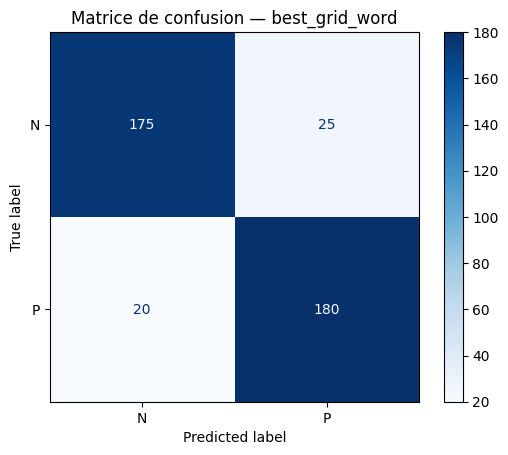

In [ ]:
cm = confusion_matrix(y_valid, y_pred, labels=["N", "P"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["N", "P"])
disp.plot(cmap="Blues")
plt.title(f"Matrice de confusion — {BEST_MODEL_NAME}")
plt.show()

## 13. Analyse rapide des erreurs

Cette cellule permet de voir quelques exemples mal classés pour comprendre :
- ambiguïté
- ironie
- mélange de sentiments
- négations complexes
- reviews très longues ou contradictoires

In [ ]:
errors_df = pd.DataFrame({
    "text": X_valid.values,
    "true_label": y_valid.values,
    "pred_label": y_pred,
})

errors_df = errors_df[errors_df["true_label"] != errors_df["pred_label"]].copy()
print("Nombre d'erreurs :", len(errors_df))
errors_df.head(15)

Nombre d'erreurs : 45


,text,true_label,pred_label
3,running time approximately hr mins reviewed by...,N,P
11,take a number fill out a form and wait your tu...,P,N
22,the blair witch project was perhaps one of a k...,P,N
23,lets face it since waterworld floated by the s...,P,N
34,a couple of criminals mario van peebles and lo...,N,P
44,mandingo has traditionally been seen as one of...,N,P
66,the following review contains some harsh langu...,N,P
77,the beach is a structurally confusing film tha...,N,P
95,steve martin is one of the funniest men alive ...,N,P
98,violence is bad violence is ugly violence bree...,N,P


## 14. Résumé interprétatif

À compléter après exécution.

Exemple de commentaires possibles :
- le meilleur gain vient-il du tuning word-level ou des char n-grams ?
- LSA apporte-t-il un vrai gain ou non ?
- les gains sont-ils faibles mais stables, ou nets ?
- les erreurs restantes semblent-elles dues à l'ironie, à l'ambiguïté, ou au manque de contexte ?

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

TEST_FILE = Path("/content/drive/MyDrive/projet tal/testSentiment.txt")

def load_test_one_review_per_line(test_file: Path) -> pd.DataFrame:
    lines = test_file.read_text(encoding="utf-8", errors="ignore").splitlines()
    rows = []
    for i, line in enumerate(lines):
        line = line.strip()
        if line:
            rows.append({
                "doc_id": i,
                "text": line
            })
    return pd.DataFrame(rows)

test_df = load_test_one_review_per_line(TEST_FILE)

test_df["text_standard"] = test_df["text"].apply(preprocess_standard)

best_submission_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(C=2.0))
])

best_submission_model.fit(df["text_standard"], df["label"])
test_pred = best_submission_model.predict(test_df["text_standard"])

submission = pd.DataFrame({
    "label": test_pred
})

display(submission.head(10))
print(submission["label"].value_counts())